Dataset Loaded!

  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  

Missing Values:
 car_name         0
year             0
selling_price    0
present_price    0
driven_kms       0
fuel_type        0
selling_type     0
transmission     0
owner            0
dtype: int64

Data Ready:
    car_name  year  selling_price  present_price  driven_kms  fuel_type  \
0        90  2014           3.35      

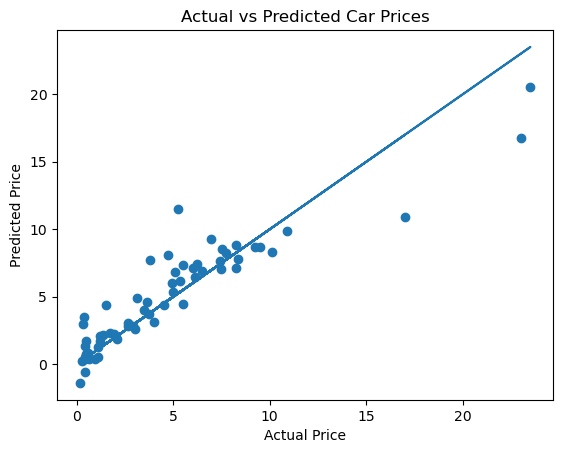


Enter Car Details to Predict Price:


Select car_name:
1. 800
2. Activa 3g
3. Activa 4g
4. Bajaj  ct 100
5. Bajaj Avenger 150
6. Bajaj Avenger 150 street
7. Bajaj Avenger 220
8. Bajaj Avenger 220 dtsi
9. Bajaj Avenger Street 220
10. Bajaj Discover 100
11. Bajaj Discover 125
12. Bajaj Dominar 400
13. Bajaj Pulsar  NS 200
14. Bajaj Pulsar 135 LS
15. Bajaj Pulsar 150
16. Bajaj Pulsar 220 F
17. Bajaj Pulsar NS 200
18. Bajaj Pulsar RS200
19. Hero  CBZ Xtreme
20. Hero  Ignitor Disc
21. Hero Extreme
22. Hero Glamour
23. Hero Honda CBZ extreme
24. Hero Honda Passion Pro
25. Hero Hunk
26. Hero Passion Pro
27. Hero Passion X pro
28. Hero Splender Plus
29. Hero Splender iSmart
30. Hero Super Splendor
31. Honda Activa 125
32. Honda Activa 4G
33. Honda CB Hornet 160R
34. Honda CB Shine
35. Honda CB Trigger
36. Honda CB Unicorn
37. Honda CB twister
38. Honda CBR 150
39. Honda Dream Yuga
40. Honda Karizma
41. Hyosung GT250R
42. KTM 390 Duke
43. KTM RC200
44. KTM RC390
45. Mahindra Mojo XT300
46. Roy

Enter number (1-98):  93
Enter year:  2004



Select Car Price Range (in lakhs):
1. 0 - 5 lakh
2. 5 - 10 lakh
3. 10 - 20 lakh
4. 20+ lakh


Enter number:  3
Enter driven_kms:  5000



Select fuel_type:
1. CNG
2. Diesel
3. Petrol


...


Select transmission:
1. Automatic
2. Manual


Enter number (1-2):  1



Select number of previous owners:
1. 0
2. 1
3. 2
4. 3


Enter number:  1



Predicted Car Price: 6.21 Lakhs


In [1]:
### 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. LOAD DATASET
df = pd.read_csv("car data.csv")   # apni file ka path

print("Dataset Loaded!\n")
print(df.head())

# 3. CLEAN DATA
df.columns = df.columns.str.strip().str.lower()

print("\nMissing Values:\n", df.isnull().sum())

df.dropna(inplace=True)

# 4. ENCODE CATEGORICAL DATA
le_dict = {}

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

print("\nData Ready:\n", df.head())

# 5. FEATURES & TARGET
if 'selling_price' in df.columns:
    target = 'selling_price'
else:
    target = df.columns[-1]

X = df.drop(columns=[target])
y = df[target]

# 6. TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 7. MODEL TRAINING
model = LinearRegression()
model.fit(X_train, y_train)

# 8. PREDICTION
y_pred = model.predict(X_test)

# 9. EVALUATION
print("\nRESULTS:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

# 10. GRAPH (WITH LINE)
plt.scatter(y_test, y_pred)

# Perfect prediction line
plt.plot(y_test, y_test)  

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()

# 11. USER INPUT
print("\nEnter Car Details to Predict Price:\n")

user_data = {}

for col in X.columns:
    
    # CATEGORICAL
    if col in le_dict:
        options = sorted(le_dict[col].classes_)
        
        print(f"\nSelect {col}:")
        for i, opt in enumerate(options, 1):
            print(f"{i}. {opt.strip()}")
        
        choice = int(input(f"Enter number (1-{len(options)}): "))
        selected_value = options[choice - 1]
        encoded_value = le_dict[col].transform([selected_value])[0]
        
        user_data[col] = encoded_value

    # OWNER
    elif col == "owner":
        print("\nSelect number of previous owners:")
        print("1. 0")
        print("2. 1")
        print("3. 2")
        print("4. 3")

        choice = int(input("Enter number: "))
        user_data[col] = [0, 1, 2, 3][choice - 1]

    # KM DRIVEN (RANGES)
    elif col == "km_driven":
        print("\nSelect KM Driven Range:")
        print("1. 0 – 10,000 (Almost New)")
        print("2. 10,000 – 30,000 (Lightly Used)")
        print("3. 30,000 – 60,000 (Moderate Use)")
        print("4. 60,000 – 100,000 (High Use)")
        print("5. 100,000+ (Very High Use)")

        choice = int(input("Enter number: "))

        if choice == 1:
            value = 5000
        elif choice == 2:
            value = 20000
        elif choice == 3:
            value = 45000
        elif choice == 4:
            value = 80000
        else:
            value = 120000

        user_data[col] = value

    # PRESENT PRICE (RANGES)
    elif col == "present_price":
        print("\nSelect Car Price Range (in lakhs):")
        print("1. 0 - 5 lakh")
        print("2. 5 - 10 lakh")
        print("3. 10 - 20 lakh")
        print("4. 20+ lakh")

        choice = int(input("Enter number: "))

        if choice == 1:
            value = 3
        elif choice == 2:
            value = 7
        elif choice == 3:
            value = 15
        else:
            value = 25

        user_data[col] = value

    # OTHER NUMERICAL
    else:
        value = float(input(f"Enter {col}: "))
        user_data[col] = value

# Convert to DataFrame
user_df = pd.DataFrame([user_data])

# 12. FINAL PREDICTION86
prediction = model.predict(user_df)

price = prediction[0]

print("\nPredicted Car Price: {:.2f} Lakhs".format(price))